# 1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#2 Load the Dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# 3 Separate features and Target variables

In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [10]:
display(X_scaled[:5])

array([[ 2.34476576,  0.98214266,  0.62855945, -0.15375759, -0.9744286 ,
        -0.04959654,  1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, -0.26333577,  0.86143887,
        -0.09251223,  1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.04901636, -0.82077735,
        -0.02584253,  1.03850269, -1.33282653],
       [ 0.93296751,  1.85618152,  0.15696608, -0.04983292, -0.76602806,
        -0.0503293 ,  1.03850269, -1.33781784],
       [-0.012881  ,  1.85618152,  0.3447108 , -0.03290586, -0.75984669,
        -0.08561576,  1.03850269, -1.33781784]])

# 4 Feature Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5 Train-Test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#6 Define Models

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# 7 Train Evaluate and Compare

In [7]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

results_df = pd.DataFrame(results).T
print("--- Model Performance Comparison ---")
print(results_df)

# Identify Best Model (lowest RMSE / highest R2)
best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]
print(f"\nBest Model Selected: {best_model_name}")

--- Model Performance Comparison ---
                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997

Best Model Selected: Decision Tree


#8. Visual Performance Validation

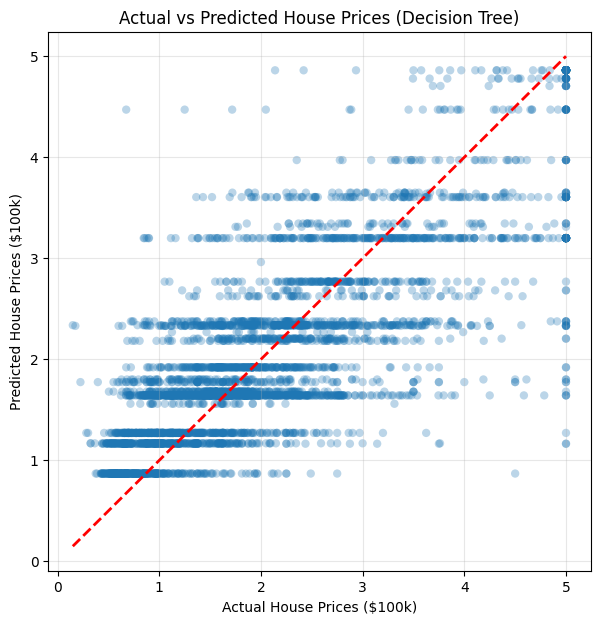

In [8]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color="#1f77b4", edgecolor="none")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", linewidth=2)
plt.xlabel("Actual House Prices ($100k)")
plt.ylabel("Predicted House Prices ($100k)")
plt.title(f"Actual vs Predicted House Prices ({best_model_name})")
plt.grid(True, alpha=0.3)
plt.show()

# Optional Deliverable: Save the Best Model


In [9]:
joblib.dump(best_model, "best_housing_model.pkl")
print(f"Saved {best_model_name} to 'best_housing_model.pkl'")

Saved Decision Tree to 'best_housing_model.pkl'


In [12]:
# List files in the current directory to see the saved model file
!ls

best_housing_model.pkl	sample_data


## Visualize the Decision Tree Structure

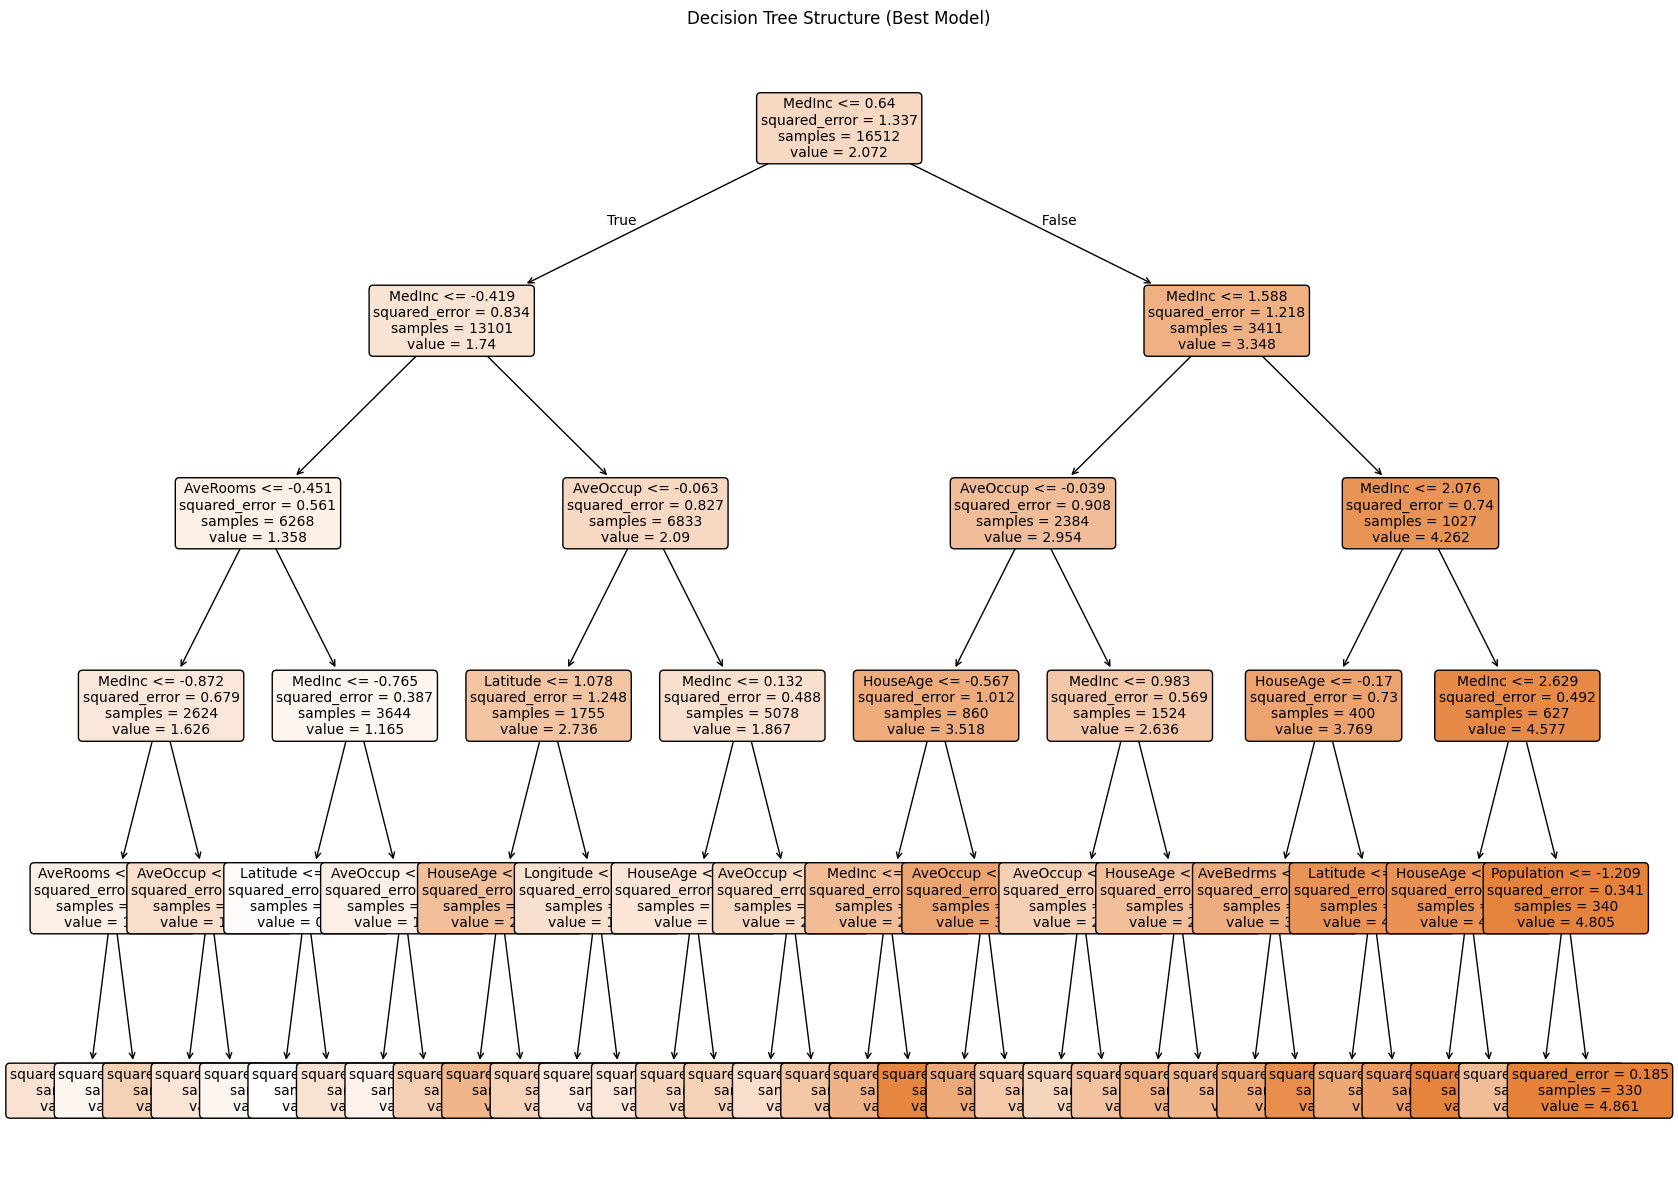

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(best_model, feature_names=X.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure (Best Model)")
plt.show()

### Feature Importance for Decision Tree Model

In [16]:
feature_importances = best_model.feature_importances_
feature_names = X.columns.tolist()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

display(importance_df)

,Feature,Importance
0,MedInc,0.771212
5,AveOccup,0.128407
1,HouseAge,0.041621
2,AveRooms,0.031261
6,Latitude,0.022049
4,Population,0.002485
7,Longitude,0.002097
3,AveBedrms,0.000869


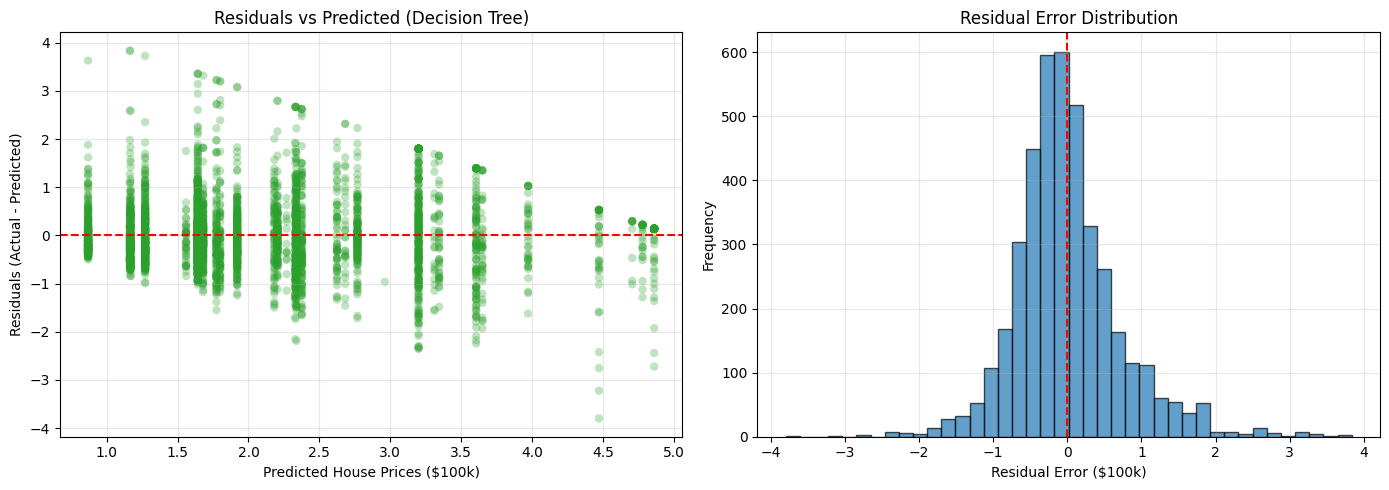

In [17]:
# Compute residuals
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals vs Predicted Values (Homoscedasticity Check)
axes[0].scatter(y_pred, residuals, alpha=0.3, color="#2ca02c", edgecolor="none")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted House Prices ($100k)")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].set_title(f"Residuals vs Predicted ({best_model_name})")
axes[0].grid(True, alpha=0.3)

# 2. Residual Distribution (Normality Check)
axes[1].hist(residuals, bins=40, color="#1f77b4", edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual Error ($100k)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Error Distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=300)
plt.show()